<a href="https://colab.research.google.com/github/Nikhilsankhyan0/Agrisheild-AI/blob/main/classification_model_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:


import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Features
x_train = pd.read_csv(
    "/content/drive/MyDrive/X_train_encoded.csv"
)

x_val = pd.read_csv(
    "/content/drive/MyDrive/X_val_encoded.csv"
)

x_test = pd.read_csv(
    "/content/drive/MyDrive/X_test_encoded.csv"
)

# Classification target
y_train_cls = pd.read_csv(
    "/content/drive/MyDrive/y_train_cls.csv"
).squeeze()

y_val_cls = pd.read_csv(
    "/content/drive/MyDrive/y_val_cls.csv"
).squeeze()

y_test_cls = pd.read_csv(
    "/content/drive/MyDrive/y_test_cls.csv"
).squeeze()

print("X_train:", x_train.shape)
print("X_val  :", x_val.shape)
print("X_test :", x_test.shape)

print("y_train:", y_train_cls.shape)
print("y_val  :", y_val_cls.shape)
print("y_test :", y_test_cls.shape)

X_train: (14000, 259)
X_val  : (3000, 259)
X_test : (3000, 259)
y_train: (14000,)
y_val  : (3000,)
y_test : (3000,)


encode loan status

In [4]:
label_encoder = LabelEncoder()

y_train_cls_encoded = label_encoder.fit_transform(
    y_train_cls
)

y_val_cls_encoded = label_encoder.transform(
    y_val_cls
)

y_test_cls_encoded = label_encoder.transform(
    y_test_cls
)

print("Class mapping:")

for class_name, class_number in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(class_name, "→", class_number)

Class mapping:
Approved → 0
Approved with Conditions → 1
Rejected → 2


scale the features


In [5]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_val_scaled = scaler.transform(x_val)

x_test_scaled = scaler.transform(x_test)

In [6]:
baseline_cls = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_cls.fit(
    x_train_scaled,
    y_train_cls_encoded
)

LogisticRegression(max_iter=1000, random_state=42)

In [7]:
y_pred_cls = baseline_cls.predict(
    x_val_scaled
)
accuracy = accuracy_score(
    y_val_cls_encoded,
    y_pred_cls
)

print("Accuracy:", accuracy)

Accuracy: 0.771


In [8]:
print(
    classification_report(
        y_val_cls_encoded,
        y_pred_cls,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

                Approved       0.79      0.75      0.77       848
Approved with Conditions       0.71      0.76      0.74      1240
                Rejected       0.84      0.80      0.82       912

                accuracy                           0.77      3000
               macro avg       0.78      0.77      0.78      3000
            weighted avg       0.77      0.77      0.77      3000



In [9]:
cm = confusion_matrix(
    y_val_cls_encoded,
    y_pred_cls
)

print(cm)

[[636 210   2]
 [164 943 133]
 [ 10 168 734]]


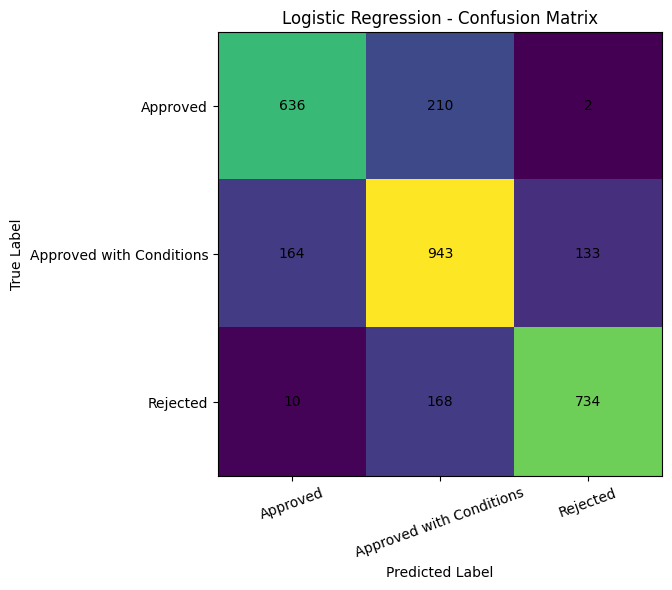

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=20
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression - Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()